# Практическая 3 (Саттаров Булат Рамилевич ЭФМО-01-25)

<h1>Задание</h1>  
С помощью метода kNN определить качество красного вина. Использовать датасет winequality-red.csv, который находится в папке data.
Для этого разделить набор данных на обучающий и тестовый набор и обучим нашу модель в обучающем наборе. 
Построить матрицу путаници. Сделать выводы по полученным результатам. 

In [110]:
import warnings
warnings.filterwarnings('ignore')

In [111]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import itertools

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (10, 5)
%matplotlib inline

In [112]:
df_raw = pd.read_csv('winequality-red.csv')
df = pd.DataFrame(df_raw)

df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [113]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [114]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [115]:
df['target'] = np.where(df['quality'] >= 7, 'Качественное', 'Некачественное')
df['target'].value_counts()

target
Некачественное    1382
Качественное       217
Name: count, dtype: int64

In [116]:
temp_df = df.copy()

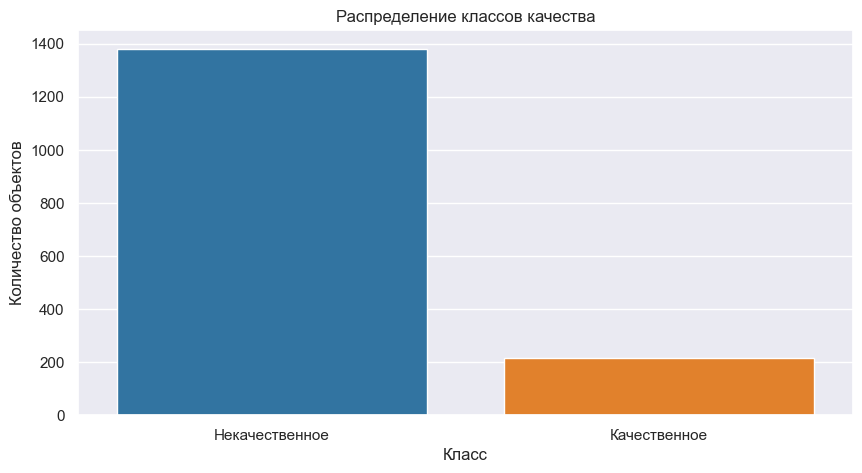

In [117]:
sns.countplot(x='target', hue='target', data=temp_df, palette='tab10')
plt.title('Распределение классов качества')
plt.xlabel('Класс')
plt.ylabel('Количество объектов')
plt.show()

Из графика выше видно, что классы распределены неравномерно.  
Некачественных вин в датасете заметно больше, чем качественных.  
Тем не менее для данной работы такой вид бинарной классификации удобен и позволяет явно разделить вина на две группы.

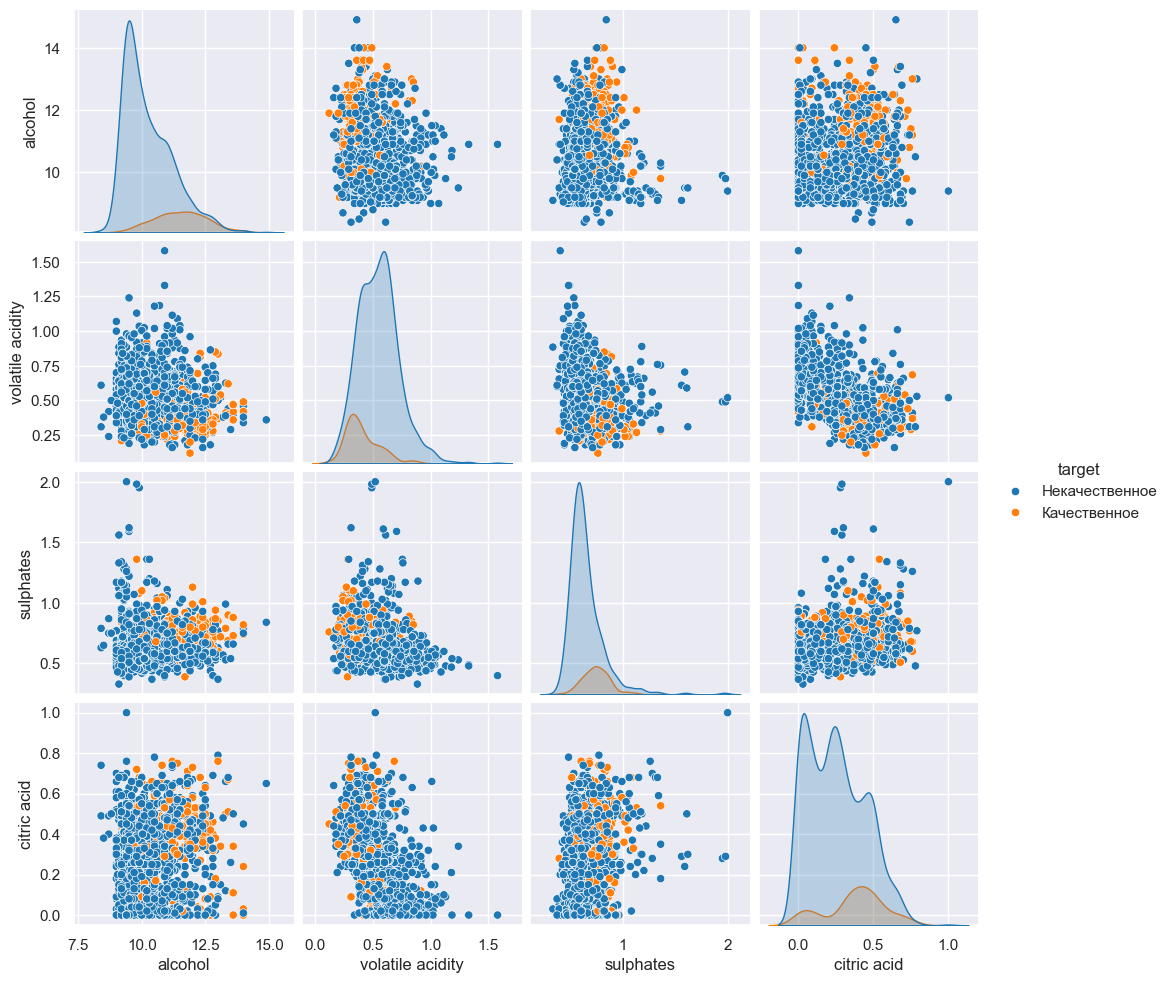

In [118]:
pairplot_columns = ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'target']
sns.pairplot(temp_df[pairplot_columns], hue='target', palette='tab10')
plt.show()

На графике выше можно увидеть взаимосвязь между наиболее показательными признаками.  
Для части объектов наблюдается пересечение классов, однако по ряду признаков можно заметить различия.  
Например, качественные вина чаще имеют более высокий `alcohol`, более низкий `volatile acidity` и несколько более высокие `sulphates`.

In [119]:
def display_confusion_matrix(
    matrix, labels=None, title="Confusion Matrix", xlabel="Predicted",
    ylabel="Actual", figsize=None, cmap="Blues", vmin=None, vmax=None
):
    if labels is None:
        labels = range(len(matrix))

    if figsize is None:
        figsize = (7, 5)

    plt.figure(figsize=figsize)
    plt.imshow(matrix, interpolation='nearest', cmap=cmap, vmin=vmin, vmax=vmax)
    plt.title(title)
    plt.colorbar()

    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels)
    plt.yticks(tick_marks, labels)

    thresh = matrix.max() / 2. if matrix.size else 0
    for i, j in itertools.product(range(matrix.shape[0]), range(matrix.shape[1])):
        plt.text(
            j, i, matrix[i, j],
            horizontalalignment="center",
            color="white" if matrix[i, j] > thresh else "black"
        )

    plt.tight_layout()
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.show()

# __Модель на разделенном наборе данных__

Теперь разделим набор данных на обучающую и тестовую выборки.  
Обучение будет выполняться на обучающей части, а оценка качества классификации – на тестовой.

In [120]:
X = df.drop(['quality', 'target'], axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    stratify=y,
    test_size=0.2,
    random_state=42
)

In [121]:
knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5))
])

knn.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])

In [122]:
preds = knn.predict(X_test)
labels = np.array(['Некачественное', 'Качественное'])
print(classification_report(y_test, preds))

                precision    recall  f1-score   support

  Качественное       0.50      0.33      0.39        43
Некачественное       0.90      0.95      0.92       277

      accuracy                           0.87       320
     macro avg       0.70      0.64      0.66       320
  weighted avg       0.85      0.87      0.85       320



[[263  14]
 [ 29  14]]


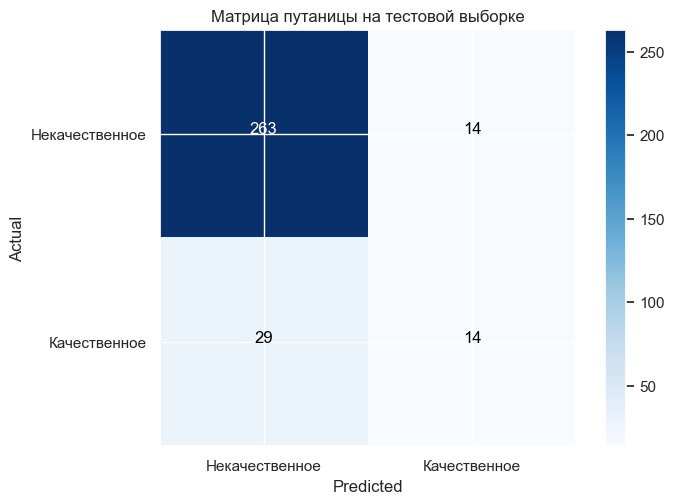

In [123]:
matrix = confusion_matrix(y_test, preds, labels=labels, normalize=None)
print(matrix)

display_confusion_matrix(matrix, labels, title='Матрица путаницы на тестовой выборке')

По матрице путаницы и отчету классификации видно, что модель лучше распознает класс некачественных вин, так как этот класс представлен в датасете сильнее.  
При этом качественные вина также отделяются по совокупности признаков, хотя ошибки классификации для них встречаются чаще.

<h1>Вывод</h1>  
В работе был применен метод k-ближайших соседей для определения качества красного вина по физико-химическим характеристикам из датасета `winequality-red.csv`.  
Целевая переменная была преобразована в два класса: качественное вино (`quality >= 7`) и некачественное вино (`quality < 7`).  
Были изучены структура и распределение данных, построены несколько моделей KNN для разных наборов признаков, а также получены матрицы путаницы.  
Наиболее качественный результат показала модель, использующая все признаки и обученная на разделенных обучающей и тестовой выборках.